# 04. ANN Training — Crop Recommendation
### Training the core multi-class classifier on the benchmark dataset (N, P, K, temperature, humidity, pH, rainfall → 15 crops)


In [2]:
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

PROC_DIR = '../data/processed/crop_recom'
MODEL_DIR = '../models'
OUT_DIR = '../outputs/notebooks_task4'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

### Load the pre-scaled benchmark split

In [3]:
data = np.load(os.path.join(PROC_DIR, 'benchmark_train_test_split.npz'))
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']

label_encoder = joblib.load(os.path.join(MODEL_DIR, 'label_encoder_benchmark.pkl'))
class_names = label_encoder.classes_
n_classes = len(class_names)

print('X_train:', X_train.shape, ' X_test:', X_test.shape)
print('Number of crop classes:', n_classes)
print('Classes:', list(class_names))

X_train: (1200, 7)  X_test: (300, 7)
Number of crop classes: 15
Classes: ['Big Onion', 'Chillies (Green)', 'Cowpea', 'Gingelly', 'Green Gram', 'Ground Nuts', 'Kurakkan', 'Maize', 'Manioc', 'Meneri', 'Mustard', 'Potatoes', 'Red Onion', 'Sorghum', 'Sweet Potatoes']


Confirm class balance carried through the stratified split from preprocessing.

In [4]:
train_counts = pd.Series(y_train).value_counts().sort_index()
train_counts.index = class_names
print(train_counts)

Big Onion           80
Chillies (Green)    80
Cowpea              80
Gingelly            80
Green Gram          80
Ground Nuts         80
Kurakkan            80
Maize               80
Manioc              80
Meneri              80
Mustard             80
Potatoes            80
Red Onion           80
Sorghum             80
Sweet Potatoes      80
Name: count, dtype: int64


In [5]:
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print('Fit:', X_train_fit.shape, ' Val:', X_val.shape)

Fit: (1020, 7)  Val: (180, 7)


### Build the ANN architecture

In [6]:
def build_ann(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), name='soil_weather_features'),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ], name='crop_recommender_ann')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

ann_model = build_ann(X_train.shape[1], n_classes)
ann_model.summary()

Model: "crop_recommender_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,375 (13.18 KB)

 Trainable params: 3,375 (13.18 KB)

 Non-trainable params: 0 (0.00 B)

### Train with early stopping

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6
    )
]

history = ann_model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print('Stopped after', len(history.history['loss']), 'epochs')
print('Best val_loss:', min(history.history['val_loss']))
print('Best val_accuracy:', max(history.history['val_accuracy']))

Epoch 1/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0717 - loss: 2.6883 - val_accuracy: 0.2278 - val_loss: 2.4921 - learning_rate: 0.0010
Epoch 2/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1957 - loss: 2.4472 - val_accuracy: 0.3833 - val_loss: 2.1000 - learning_rate: 0.0010
Epoch 3/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3328 - loss: 2.0453 - val_accuracy: 0.5167 - val_loss: 1.5744 - learning_rate: 0.0010
Epoch 4/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4177 - loss: 1.5912 - val_accuracy: 0.5611 - val_loss: 1.2732 - learning_rate: 0.0010
Epoch 5/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4557 - loss: 1.3807 - val_accuracy: 0.5889 - val_loss: 1.1218 - learning_rate: 0.0010
Epoch 6/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5005 - loss: 1.2462 - val_accuracy: 0.6167 - val_loss: 1.0452 - learning_rate: 0.0010
Epoch 7/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5340 - loss: 1.1461 - val_acc

### Training curves

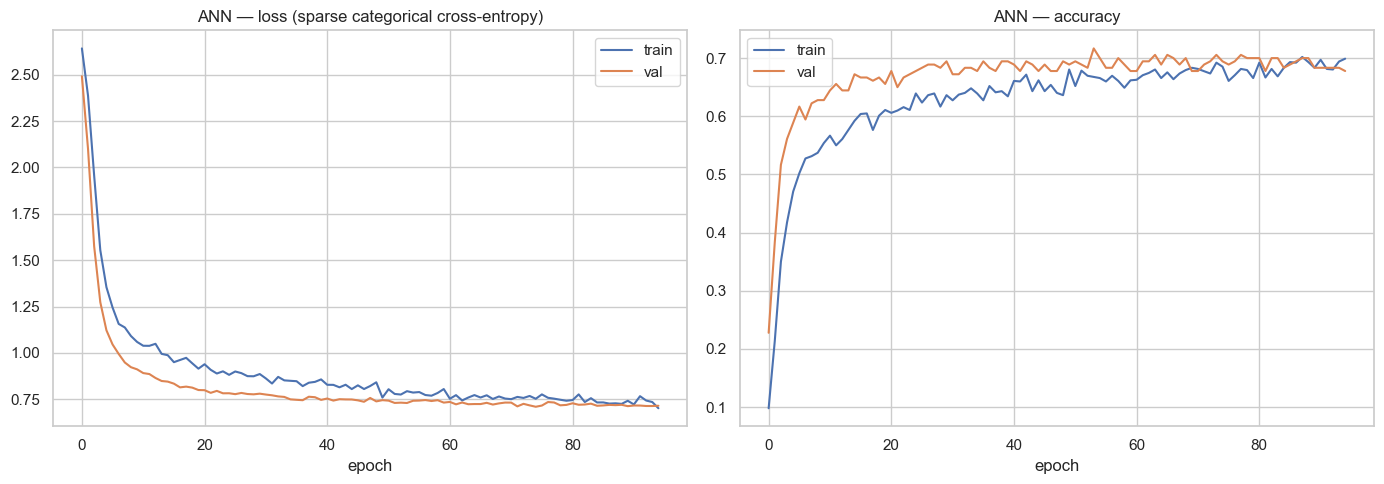

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('ANN — loss (sparse categorical cross-entropy)')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('ANN — accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '01_ann_training_curves.png'), dpi=120)
plt.show()

## 6. Evaluate on the held-out test set

In [9]:
test_loss, test_acc = ann_model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

y_pred_probs = ann_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro'
)
print(f'Macro precision: {precision:.4f}')
print(f'Macro recall:    {recall:.4f}')
print(f'Macro F1:        {f1:.4f}')

Test loss: 0.6804
Test accuracy: 0.7300
Macro precision: 0.7399
Macro recall:    0.7300
Macro F1:        0.7128


### Per-class precision / recall / F1

In [13]:
report = classification_report(
    y_test, y_pred, target_names=class_names, digits=3
)
print(report)

with open(os.path.join(OUT_DIR, '04_ann_classification_report.txt'), 'w') as f:
    f.write(report)

                  precision    recall  f1-score   support

       Big Onion      0.606     1.000     0.755        20
Chillies (Green)      0.867     0.650     0.743        20
          Cowpea      0.579     0.550     0.564        20
        Gingelly      0.625     0.250     0.357        20
      Green Gram      0.952     1.000     0.976        20
     Ground Nuts      0.517     0.750     0.612        20
        Kurakkan      0.471     0.400     0.432        20
           Maize      0.800     1.000     0.889        20
          Manioc      0.826     0.950     0.884        20
          Meneri      0.500     0.700     0.583        20
         Mustard      1.000     0.900     0.947        20
        Potatoes      1.000     1.000     1.000        20
       Red Onion      0.667     0.200     0.308        20
         Sorghum      0.800     0.800     0.800        20
  Sweet Potatoes      0.889     0.800     0.842        20

        accuracy                          0.730       300
       macro

### Confusion matrix

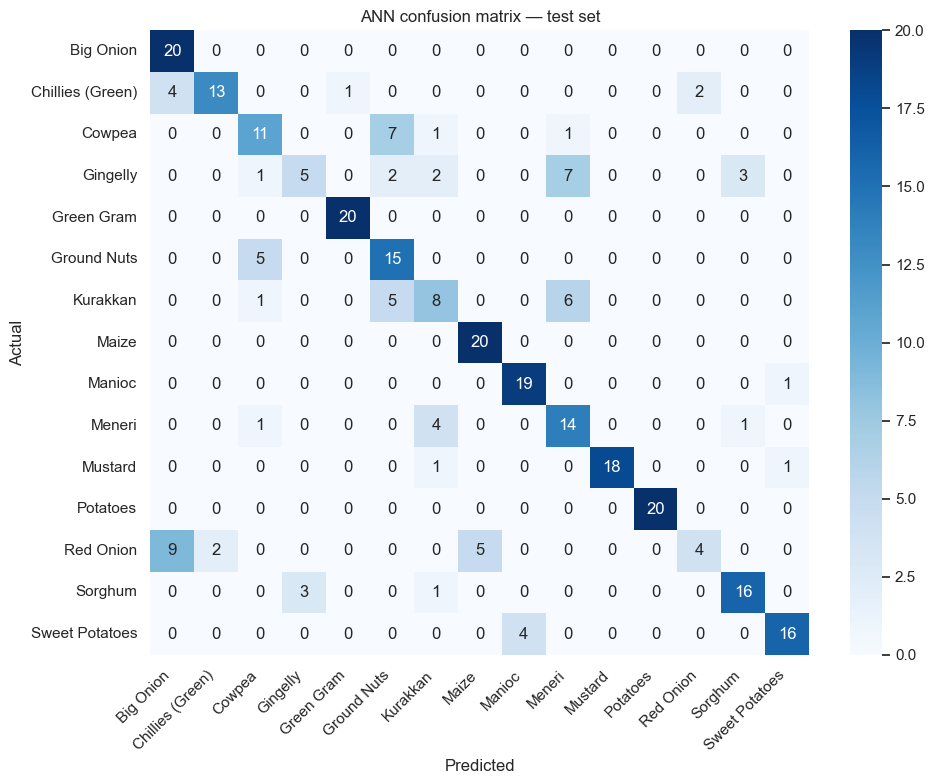

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN confusion matrix — test set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '02_ann_confusion_matrix.png'), dpi=120)
plt.show()

## 7. Sanity check — inspect a few individual predictions

In [14]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=5, replace=False)

for idx in sample_idx:
    probs = y_pred_probs[idx]
    top3_idx = np.argsort(probs)[::-1][:3]
    actual = class_names[y_test[idx]]
    top3 = [(class_names[i], round(float(probs[i]), 3)) for i in top3_idx]
    print(f'Actual: {actual:20s}  ->  Top-3 predicted: {top3}')

Actual: Kurakkan              ->  Top-3 predicted: [('Ground Nuts', 0.339), ('Kurakkan', 0.295), ('Cowpea', 0.155)]
Actual: Sweet Potatoes        ->  Top-3 predicted: [('Sweet Potatoes', 0.953), ('Manioc', 0.047), ('Potatoes', 0.0)]
Actual: Green Gram            ->  Top-3 predicted: [('Green Gram', 0.999), ('Chillies (Green)', 0.001), ('Cowpea', 0.0)]
Actual: Potatoes              ->  Top-3 predicted: [('Potatoes', 1.0), ('Chillies (Green)', 0.0), ('Sweet Potatoes', 0.0)]
Actual: Big Onion             ->  Top-3 predicted: [('Big Onion', 0.582), ('Maize', 0.201), ('Red Onion', 0.188)]


### Save the trained model, training history, and headline metrics

In [15]:
ann_model.save(os.path.join(MODEL_DIR, 'ann_crop_recommender.keras'))

with open(os.path.join(MODEL_DIR, 'ann_training_history.json'), 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f)

ann_results = {
    'model': 'ANN',
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'macro_precision': float(precision),
    'macro_recall': float(recall),
    'macro_f1': float(f1)
}

with open(os.path.join(OUT_DIR, '04_ann_results.json'), 'w') as f:
    json.dump(ann_results, f, indent=2)

print('Saved model  ->', os.path.join(MODEL_DIR, 'ann_crop_recommender.keras'))
print('Saved metrics ->', ann_results)

Saved model  -> ../models\ann_crop_recommender.keras
Saved metrics -> {'model': 'ANN', 'test_accuracy': 0.7300000190734863, 'test_loss': 0.6803742051124573, 'macro_precision': 0.7399018480140691, 'macro_recall': 0.7300000000000001, 'macro_f1': 0.7128143850720955}
